DEBUG:matplotlib.pyplot:Loaded backend inline version unknown.


[array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]]), array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]]), array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])]


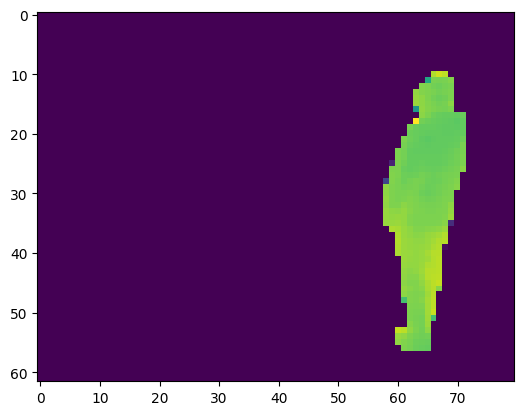

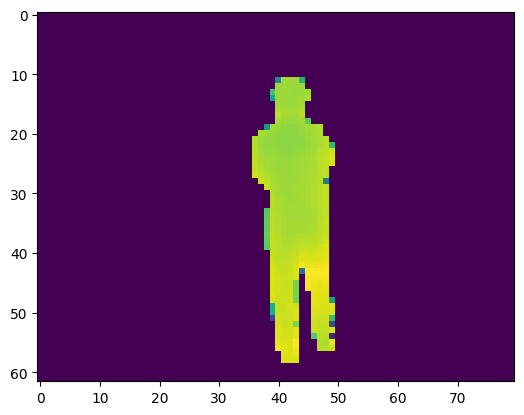

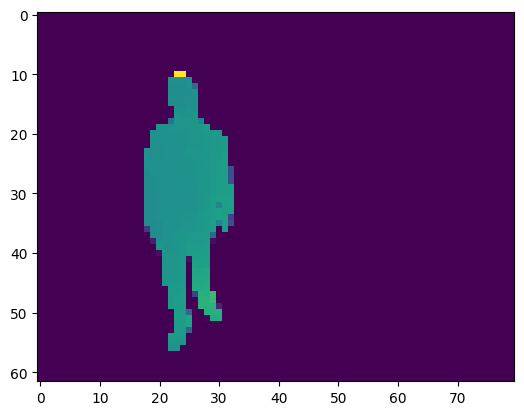

In [4]:
from data_collection import process_mask, put_text
import pickle as pkl
%matplotlib inline
import matplotlib.pyplot as plt
# import matplotlib.pyplot as plt

# load a pkl file: /home/zx/Desktop/zx/TAP3D_demo/data/test_multi/annotation/1739545325.pkl
with open("/home/zx/Desktop/zx/TAP3D_demo/data/test_multi/annotation/1739545325.pkl", "rb") as f:
    result_dict = pkl.load(f)

# process_mask(depth_masks)
print(result_dict['depth_mask_person'])

plt.imshow(result_dict['depth_mask_person'][0])
plt.show()
plt.imshow(result_dict['depth_mask_person'][1])
plt.show()
plt.imshow(result_dict['depth_mask_person'][2])
plt.show()

DEBUG: PROCESSING MASK!!!!!!!


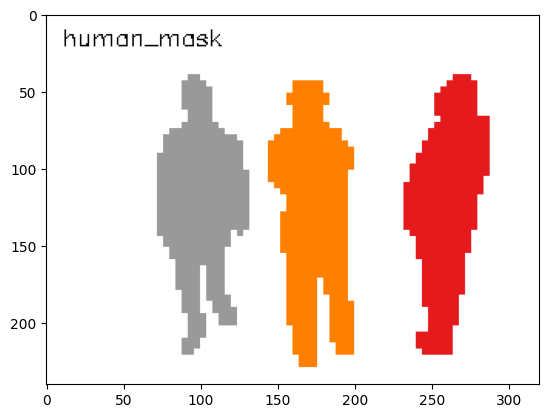

In [5]:
import numpy as np
import cv2
def process_mask(result_dict):
    '''
    Make a mask on white background
    each human is assigned a color
    '''
    print("DEBUG: PROCESSING MASK!!!!!!!")
    mask = None

    # Get colors for each person
    colors = plt.colormaps.get_cmap('Set1')(np.linspace(0, 1, result_dict['num_persons']))
    for i in range(result_dict['num_persons']):
        if mask is None:
            # make a white mask with shape same as result_dict['depth_mask_person']
            mask = np.zeros_like(result_dict["depth_mask_person"][0])
            mask[:] = 255
            # repeat to 3 channels
            mask = np.stack([mask] * 3, axis=-1)

        mask[result_dict["depth_mask_person"][i] > 0] = (np.array(colors[i][:3])*255).astype(np.uint8)
        # print all uniq values in mask
        # print("Uniq values in mask:", np.unique(mask))

    if mask is None:
        mask = np.ones((240, 320, 3), dtype=np.uint8)*255
        
    mask = mask.astype(np.uint8)
    mask = cv2.resize(mask, (320, 240), interpolation=cv2.INTER_NEAREST)
    # mask = cv2.applyColorMap(mask, cv2.COLORMAP_JET)
    # write on the top-left of the mask: "human mask"
    put_text(mask, "human_mask")

    return mask

mask = process_mask(result_dict)
plt.imshow(mask)
plt.show()